# True Sale GS — Análise de Performance do Portfólio
**Mercado Pago × Goldman Sachs | Whole Loan Forward Flow**

Análise das métricas de performance do portfólio vendido ao GS, baseada em dados do BigQuery.
Todas as queries estão documentadas abaixo de cada seção.

**Arquivos necessários no Google Drive (MyDrive/):**
| Arquivo | Fonte |
|---------|-------|
| `True Sale GS.xlsx` | Manual (planilha de histórico) |
| `over30_merch.csv` | Query BQ — Merchant OVER 30 |
| `rating_mix_merch.csv` | Query BQ — Rating Mix Merchant |
| `over30_cons.csv` | Query BQ — Consumer OVER 30 |
| `rating_mix_cons.csv` | Query BQ — Rating Mix Consumer |
| `product_mix_cons.csv` | Query BQ — Mix de Produto Consumer |


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.interpolate import make_interp_spline

drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive'

def smooth(x, y, n=300):
    if len(x) < 4: return x, y
    spl = make_interp_spline(x, y, k=3)
    xs = np.linspace(x.min(), x.max(), n)
    return xs, spl(xs)


Mounted at /content/drive


---
## 1. Trailing Delinquency — Merchant GS (30DPD Roll Rate)

**O que é:** percentual do portfólio Merchant que transitou de adimplente para 30+ dias de atraso em cada mês.

**Gatilho GS (Merchant):** média 3M > **6%** → evento de terminação do programa.

**Fonte:** `meli-bi-data.SBOX_SBCREDBIREP3EROS.DM_CALCULO_TRAILING_BUCKETS_MERCH_GS_MLB`


In [ ]:
query_trailing_merch = '''
-- Trailing Delinquency Merchant GS — histórico completo
-- Tabela: meli-bi-data.SBOX_SBCREDBIREP3EROS.DM_CALCULO_TRAILING_BUCKETS_MERCH_GS_MLB

WITH dedup AS (
  SELECT *,
    ROW_NUMBER() OVER (PARTITION BY DATA_DE_CALCULO ORDER BY LAST_UPDATE DESC) AS rn
  FROM `meli-bi-data.SBOX_SBCREDBIREP3EROS.DM_CALCULO_TRAILING_BUCKETS_MERCH_GS_MLB`
)
SELECT
  DATA_DE_CALCULO            AS mes,
  ROUND(MONTH_PORT_DEL_M, 2) AS delinquency_mensal_pct,
  ROUND(MOVING_AVG, 2)       AS media_3m_pct,
  VALID_NIVEL_1              AS flag_mensal,
  VALID_NIVEL_2              AS flag_media_3m
FROM dedup
WHERE rn = 1
ORDER BY DATA_DE_CALCULO ASC
-- Salvar como: True Sale GS.xlsx (aba Histórico Deliquency)
'''
# print(query_trailing_merch)


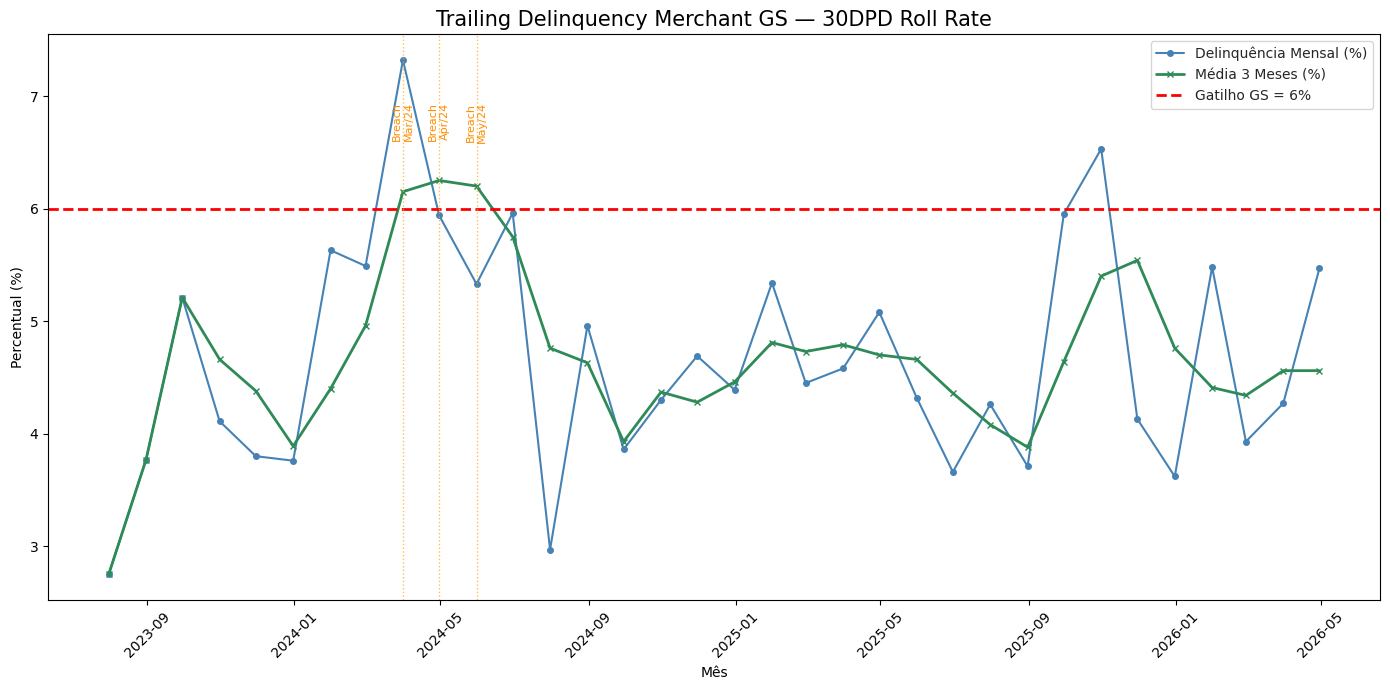

Meses com breach da média 3M > 6%: ['Mar/24', 'Apr/24', 'May/24']


In [ ]:
file_path = f'{DRIVE}/True Sale GS.xlsx'
df_delinquency = pd.read_excel(file_path, sheet_name='Histórico Deliquency')
df_delinquency['mes'] = pd.to_datetime(df_delinquency['mes'])
df_delinquency['threshold_gs'] = 6.0

fig, ax = plt.subplots(figsize=(14, 7))
sns.set_style('whitegrid')

ax.plot(df_delinquency['mes'], df_delinquency['delinquency_mensal_pct'],
        marker='o', color='steelblue', label='Delinquência Mensal (%)', linewidth=1.5, markersize=4)
ax.plot(df_delinquency['mes'], df_delinquency['media_3m_pct'],
        marker='x', color='seagreen', label='Média 3 Meses (%)', linewidth=2, markersize=5)
ax.axhline(y=6, color='red', linestyle='--', linewidth=2, label='Gatilho GS = 6%')

# Marca meses de breach
breach_meses = df_delinquency[df_delinquency['media_3m_pct'] > 6]
for _, row in breach_meses.iterrows():
    ax.axvline(row['mes'], color='orange', linestyle=':', lw=1, alpha=0.7)
    ax.text(row['mes'], ax.get_ylim()[1] * 0.92,
            f"Breach\n{row['mes'].strftime('%b/%y')}",
            rotation=90, va='top', ha='center', color='darkorange', fontsize=8)

ax.set_title('Trailing Delinquency Merchant GS — 30DPD Roll Rate', fontsize=15)
ax.set_xlabel('Mês')
ax.set_ylabel('Percentual (%)')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Meses com breach da média 3M > 6%: {list(breach_meses['mes'].dt.strftime('%b/%y'))}")


**Conclusão:** Historicamente a média 3M ficou abaixo de 6% em ~91% dos meses.
O único breach aconteceu em **mar–mai/2024** (pico de 7,32% em março), e o portfólio
se recuperou em 4 meses sem intervenção. Nos últimos 6 meses a média está em ~4,5%.

> Argumento: se o contrato usasse 6% em 2024, o programa teria sido suspenso por 3 meses.
> Base para negociar o gatilho para 6,5% ou 7%.


---
## 2. Merchant — Chuveirinho OVER 30 (Vintage Analysis)

**O que é:** agrupa os empréstimos por mês de originação (vintage) e acompanha o % do valor original
que entra em 30+ dias de atraso ao longo do tempo (MOB = Months on Book).

**Gatilhos GS Merchant por MOB:**
| MOB | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10+ |
|-----|---|---|---|---|---|---|---|---|-----|
| Trigger | 8% | 11% | 15% | 16% | 16% | 17% | 18% | 19% | 19.5% |

**Fontes:** `BT_MP_CREDITS_CREDIT_DETAIL` + `DM_CRD_ACCOUNTING`


In [ ]:
query_over30_merch = '''
-- Chuveirinho OVER 30 — Merchant GS
-- Salvar como: over30_merch.csv

WITH ORIG AS (
  SELECT
    LAST_DAY(CRD_CREDIT_CREATION_DATE_ID) AS Credit_Creation_Month,
    SUM(CRD_CREDIT_REQ_AMOUNT)            AS Total_Amount
  FROM `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL`
  WHERE
    CUS_CUST_ID_BPARTNER = 571062534
    AND CUS_CUST_ID_LENDER = 399304599
    AND CRD_CREDIT_CREATION_DT_ID >= \'2023-01-01\'
    AND CRD_CREDIT_STATUS_ID NOT IN (\'REFINANCED\',\'PENDING\',\'ANNULLED\',\'APPROVED\',\'CANCELLED\')
    AND CRD_PRODUCT_ID IN (
      \'MER_MLB_1\',\'MER_MLB_MA\',\'MER_MLB_SFO\',\'MLB_EO_ONLINE\',\'POINT_MLB_FO_RNV\',
      \'MER_MLB_FO_RNV\',\'POINT_MLB_1\',\'POINT_MLB_STD\',\'EXPRESS_POINT_MLB_1\',
      \'EXPRESS_MLB_1\',\'BABY_EXPRESS_POINT_MLB_1\',\'EXPRESS_MA_MLB\',\'CDB_DE_28\',
      \'SPL_MER_MLB_EO_1\',\'SPL_POINT_MLB_FO_1\',\'SPL_POINT_MLB_EO_1\',\'SPL_MER_MLB_FO_1\',
      \'FUNDING_MLB\',\'CHECKOUT_MLB\'
    )
  GROUP BY 1
),
PORT AS (
  SELECT
    LAST_DAY(TIM_DAY)                              AS Reference_Month,
    LAST_DAY(CRD.CRD_CREDIT_CREATION_DATE_ID)     AS Credit_Creation_Month,
    SUM(ACC.REM_CAP)                               AS Remaining_Capital
  FROM `meli-bi-data.WHOWNER.DM_CRD_ACCOUNTING` AS ACC
  LEFT JOIN `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL` AS CRD
    ON CRD.CRD_CREDIT_ID = ACC.CRD_CREDIT_ID
  WHERE
    TIM_DAY = LAST_DAY(TIM_DAY) AND TIM_DAY >= \'2023-01-01\'
    AND (ACC.CRD_CREDIT_STATUS_ID IN (\'CREDITED\',\'ON_TIME\',\'OVERDUE\',\'FINISHED\') OR ACC.CRD_CREDIT_STATUS_ID IS NULL)
    AND CRD.CRD_PRODUCT_ID IN (
      \'MER_MLB_1\',\'MER_MLB_MA\',\'MER_MLB_SFO\',\'MLB_EO_ONLINE\',\'POINT_MLB_FO_RNV\',
      \'MER_MLB_FO_RNV\',\'POINT_MLB_1\',\'POINT_MLB_STD\',\'EXPRESS_POINT_MLB_1\',
      \'EXPRESS_MLB_1\',\'BABY_EXPRESS_POINT_MLB_1\',\'EXPRESS_MA_MLB\',\'CDB_DE_28\',
      \'SPL_MER_MLB_EO_1\',\'SPL_POINT_MLB_FO_1\',\'SPL_POINT_MLB_EO_1\',\'SPL_MER_MLB_FO_1\',
      \'FUNDING_MLB\',\'CHECKOUT_MLB\'
    )
    AND ACC.CUS_CUST_ID_LENDER IN (399304599)
    AND DPD >= 30
  GROUP BY 1, 2
)
SELECT
  PORT.Credit_Creation_Month,
  DATE_DIFF(PORT.Reference_Month, PORT.Credit_Creation_Month, MONTH) AS MOB,
  ROUND(PORT.Remaining_Capital / ORIG.Total_Amount, 4)               AS OVER_30
FROM PORT
LEFT JOIN ORIG ON ORIG.Credit_Creation_Month = PORT.Credit_Creation_Month
WHERE DATE_DIFF(PORT.Reference_Month, PORT.Credit_Creation_Month, MONTH) BETWEEN 2 AND 18
ORDER BY 1, 2
'''
# print(query_over30_merch)


Rows: 527 | Vintages: 39
OVER_30: 3.93% a 18.44%


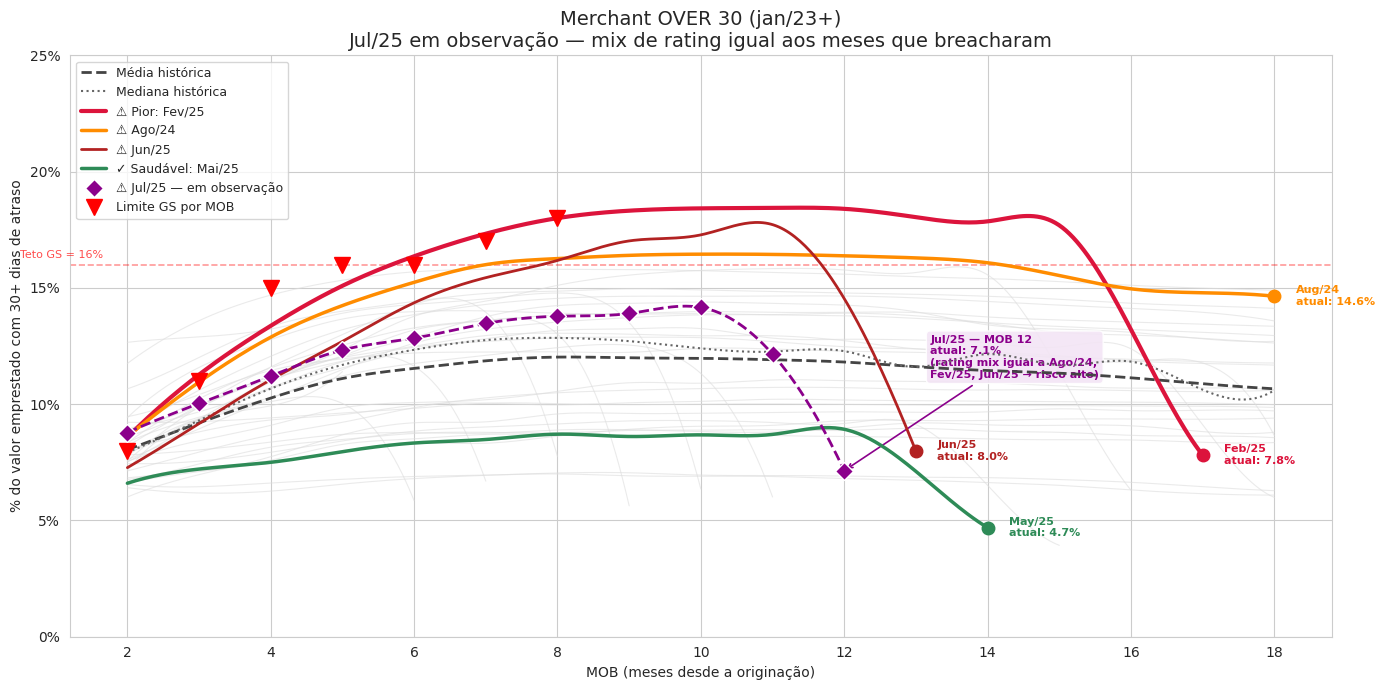

In [22]:
df_merch = pd.read_csv(f'{DRIVE}/over30_merch.csv')
df_merch['Credit_Creation_Month'] = pd.to_datetime(df_merch['Credit_Creation_Month'])
print(f"Rows: {len(df_merch)} | Vintages: {df_merch['Credit_Creation_Month'].nunique()}")
print(f"OVER_30: {df_merch['OVER_30'].min():.2%} a {df_merch['OVER_30'].max():.2%}")

df_plot = df_merch[(df_merch['MOB'] >= 2) & (df_merch['MOB'] <= 18)].sort_values(['Credit_Creation_Month','MOB'])

triggers_merch = {2:0.08, 3:0.11, 4:0.15, 5:0.16, 6:0.16, 7:0.17, 8:0.18}

DESTAQUES = {
    '2025-02-28': ('crimson',    3.0, '⚠ Pior: Fev/25'),
    '2024-08-31': ('darkorange', 2.5, '⚠ Ago/24'),
    '2025-06-30': ('firebrick',  2.0, '⚠ Jun/25'),
    '2025-05-31': ('seagreen',   2.5, '✓ Saudável: Mai/25'),
}
# Jul/25: mesmos ratings ruins que meses que breacharam — em observação
OBSERVACAO = '2025-07-31'

fig, ax = plt.subplots(figsize=(14, 7))

for vintage in sorted(df_plot['Credit_Creation_Month'].unique()):
    vstr = pd.Timestamp(vintage).strftime('%Y-%m-%d')
    if vstr in DESTAQUES or vstr == OBSERVACAO: continue
    data = df_plot[df_plot['Credit_Creation_Month'] == vintage].sort_values('MOB')
    if len(data) < 4: continue
    xs, ys = smooth(data['MOB'].values, data['OVER_30'].values)
    ax.plot(xs, ys, color='#DDDDDD', linewidth=0.8, alpha=0.6, zorder=1)

media   = df_plot.groupby('MOB')['OVER_30'].mean().reset_index().sort_values('MOB')
mediana = df_plot.groupby('MOB')['OVER_30'].median().reset_index().sort_values('MOB')
xs_m,   ys_m   = smooth(media['MOB'].values,   media['OVER_30'].values)
xs_med, ys_med = smooth(mediana['MOB'].values, mediana['OVER_30'].values)
ax.plot(xs_m,   ys_m,   color='#444444', linewidth=2,   linestyle='--', zorder=4, label='Média histórica')
ax.plot(xs_med, ys_med, color='#666666', linewidth=1.5, linestyle=':',  zorder=4, label='Mediana histórica')

for vstr, (color, lw, label) in DESTAQUES.items():
    data = df_plot[df_plot['Credit_Creation_Month'] == pd.Timestamp(vstr)].sort_values('MOB')
    if len(data) < 4: continue
    xs, ys = smooth(data['MOB'].values, data['OVER_30'].values)
    ax.plot(xs, ys, color=color, linewidth=lw, zorder=5, label=label)
    last_mob, last_val = data['MOB'].iloc[-1], data['OVER_30'].iloc[-1]
    ax.plot(last_mob, last_val, 'o', color=color, markersize=9, zorder=7)
    ax.text(last_mob+0.3, last_val, f"{pd.Timestamp(vstr).strftime('%b/%y')}\natual: {last_val:.1%}",
            color=color, fontsize=8, fontweight='bold', va='center')

# Jul/25: em observação — rating mix igual aos meses que breacharam
obs_data = df_plot[df_plot['Credit_Creation_Month'] == pd.Timestamp(OBSERVACAO)].sort_values('MOB')
if len(obs_data) >= 1:
    obs_mob = obs_data['MOB'].values
    obs_val = obs_data['OVER_30'].values
    # Linha conectando os pontos
    if len(obs_mob) >= 4:
        xs_obs, ys_obs = smooth(obs_mob, obs_val)
        ax.plot(xs_obs, ys_obs, color='#8B008B', linewidth=2.0, linestyle='--', zorder=6)
    else:
        ax.plot(obs_mob, obs_val, color='#8B008B', linewidth=2.0, linestyle='--', zorder=6)
    # Marcadores em cima da linha
    ax.plot(obs_mob, obs_val, 'D', color='#8B008B', markersize=9, zorder=8,
            label='⚠ Jul/25 — em observação', markeredgecolor='white', markeredgewidth=1.0)
    # Anotação no último ponto
    ax.annotate(
        f"Jul/25 — MOB {int(obs_mob[-1])}\natual: {obs_val[-1]:.1%}\n(rating mix igual a Ago/24,\nFev/25, Jun/25 → risco alto)",
        xy=(obs_mob[-1], obs_val[-1]),
        xytext=(obs_mob[-1] + 1.2, obs_val[-1] + 0.04),
        color='#8B008B', fontsize=8, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#8B008B', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#f3e5f5', alpha=0.9)
    )
else:
    # Sem dados ainda (vintage muito recente) — marca no eixo X como alerta
    ax.axvline(x=2, color='#8B008B', linestyle=':', linewidth=1.5, alpha=0.5,
               label='⚠ Jul/25 — em observação (dados em breve)')
    ax.text(2.1, 0.22, 'Jul/25\nem observação\n(rating ruim)', color='#8B008B',
            fontsize=8, fontweight='bold', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f3e5f5', alpha=0.85))

first = True
for mob, val in triggers_merch.items():
    ax.plot(mob, val, 'rv', markersize=11, zorder=7, label='Limite GS por MOB' if first else '_')
    first = False

ax.axhline(y=0.16, color='red', linestyle='--', linewidth=1.2, alpha=0.4)
ax.text(0.5, 0.163, 'Teto GS = 16%', color='red', fontsize=8, alpha=0.7)
ax.set_ylim(0, 0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Merchant OVER 30 (jan/23+)\nJul/25 em observação — mix de rating igual aos meses que breacharam', fontsize=14)
ax.set_xlabel('MOB (meses desde a originação)')
ax.set_ylabel('% do valor emprestado com 30+ dias de atraso')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


**Conclusão:** 3 vintages ultrapassaram o limite de 16%: **Ago/24**, **Fev/25** e **Jun/25**.
O pico mais severo foi Fev/25 (~18.4%). Todos estão em queda — o pior já passou.
Vintages recentes como Abr/25 e Mai/25 estão bem abaixo do limite.


---
## 3. Merchant — Mix de Rating por Vintage

**Por que isso importa?** Os breaches de Ago/24, Fev/25 e Jun/25 não foram aleatórios.
O rating (A = melhor, H = pior) é atribuído no momento da originação.
Em Jun/24, 83% do volume era A+B. A partir de Ago/24, E/F/G explodiram para mais de 50%.

**Fonte:** `BT_MP_CREDITS_CREDIT_DETAIL`


In [ ]:
query_rating_mix_merch = '''
-- Mix de Rating — Merchant GS
-- Salvar como: rating_mix_merch.csv

WITH base AS (
  SELECT
    LAST_DAY(CRD_CREDIT_CREATION_DATE_ID)  AS mes,
    CRD_RISK_ANALYSIS_RATING_ID            AS rating,
    COUNT(*)                               AS qtd,
    SUM(CRD_CREDIT_REQ_AMOUNT)             AS volume
  FROM `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL`
  WHERE
    CRD_CREDIT_CREATION_DT_ID BETWEEN \'2024-06-01\'  AND \'2025-07-31\'
    AND CUS_CUST_ID_BPARTNER = 571062534
    AND CUS_CUST_ID_LENDER   = 399304599
    AND CRD_CREDIT_STATUS_ID NOT IN (\'REFINANCED\',\'PENDING\',\'ANNULLED\',\'APPROVED\',\'CANCELLED\')
    AND CRD_PRODUCT_ID IN (
      \'MER_MLB_1\',\'MER_MLB_MA\',\'MER_MLB_SFO\',\'MLB_EO_ONLINE\',\'POINT_MLB_FO_RNV\',
      \'MER_MLB_FO_RNV\',\'POINT_MLB_1\',\'POINT_MLB_STD\',\'EXPRESS_POINT_MLB_1\',
      \'EXPRESS_MLB_1\',\'BABY_EXPRESS_POINT_MLB_1\',\'EXPRESS_MA_MLB\',\'CDB_DE_28\',
      \'SPL_MER_MLB_EO_1\',\'SPL_POINT_MLB_FO_1\',\'SPL_POINT_MLB_EO_1\',\'SPL_MER_MLB_FO_1\',
      \'FUNDING_MLB\',\'CHECKOUT_MLB\'
    )
  GROUP BY 1, 2
),
totais AS (SELECT mes, SUM(volume) AS total FROM base GROUP BY 1)
SELECT b.mes, b.rating, b.qtd,
  ROUND(b.volume/1e6, 2) AS volume_mm, ROUND(b.volume/t.total, 4) AS pct_volume
FROM base b JOIN totais t ON t.mes = b.mes
ORDER BY 1, 2
'''
# print(query_rating_mix_merch)


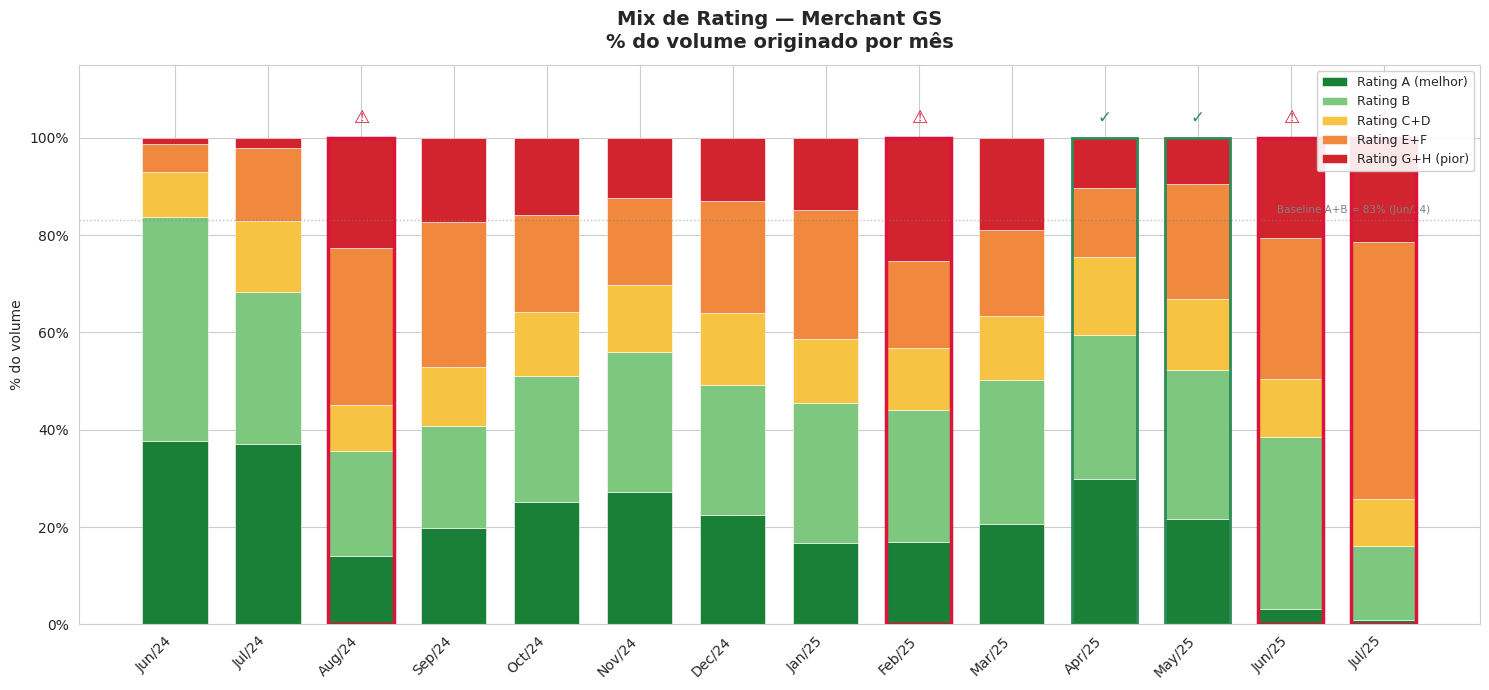

In [ ]:
df_rm = pd.read_csv(f'{DRIVE}/rating_mix_merch.csv')
df_rm['mes'] = pd.to_datetime(df_rm['mes'])

def grupo_merch(r):
    if r == 'A': return 'A'
    if r == 'B': return 'B'
    if r in ('C','D'): return 'CD'
    if r in ('E','F'): return 'EF'
    if r in ('G','H'): return 'GH'
    return None

df_rm['grupo'] = df_rm['rating'].apply(grupo_merch)
df_rm = df_rm.dropna(subset=['grupo'])
totais = df_rm.groupby('mes')['volume_mm'].sum().rename('total')
df_rm  = df_rm.join(totais, on='mes')
df_rm['pct'] = df_rm['volume_mm'] / df_rm['total']

df_piv = (df_rm.groupby(['mes','grupo'])['pct'].sum()
          .reset_index().pivot(index='mes', columns='grupo', values='pct').fillna(0).reset_index())
df_piv['label'] = df_piv['mes'].dt.strftime('%b/%y')

MESES_RUINS = {'2024-08-31','2025-02-28','2025-06-30','2025-07-31'}
MESES_BONS  = {'2025-04-30','2025-05-31'}
GRUPOS      = ['A','B','CD','EF','GH']
CORES       = ['#1a7f37','#7dc87e','#f6c343','#f0883e','#d1242f']
LABELS_LEG  = ['Rating A (melhor)','Rating B','Rating C+D','Rating E+F','Rating G+H (pior)']

fig, ax = plt.subplots(figsize=(15, 7))
xs      = range(len(df_piv))
bottoms = [0.0] * len(df_piv)

for grupo, cor, leg in zip(GRUPOS, CORES, LABELS_LEG):
    vals = df_piv[grupo].values if grupo in df_piv.columns else [0]*len(df_piv)
    ax.bar(xs, vals, bottom=bottoms, color=cor, label=leg, width=0.7, edgecolor='white', linewidth=0.4)
    bottoms = [b+v for b,v in zip(bottoms, vals)]

for i, row in df_piv.iterrows():
    ms = row['mes'].strftime('%Y-%m-%d')
    if ms in MESES_RUINS:
        ax.bar(i, 1.0, bottom=0, color='none', edgecolor='crimson', linewidth=2.5, width=0.7, zorder=5)
        ax.text(i, 1.03, '⚠', ha='center', fontsize=13, color='crimson')
    elif ms in MESES_BONS:
        ax.bar(i, 1.0, bottom=0, color='none', edgecolor='seagreen', linewidth=2.0, width=0.7, zorder=5)
        ax.text(i, 1.03, '✓', ha='center', fontsize=12, color='seagreen')

ax.set_xticks(list(xs))
ax.set_xticklabels(df_piv['label'].tolist(), rotation=45, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1.15)
ax.set_title('Mix de Rating — Merchant GS\n% do volume originado por mês', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('% do volume')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.axhline(y=0.831, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(len(df_piv)-0.5, 0.845, 'Baseline A+B = 83% (Jun/24)', color='gray', fontsize=7.5, ha='right')
plt.tight_layout()
plt.show()


| Período | A+B (bons) | E+F+G+H (risco) | Diagnóstico |
|---------|-----------|-----------------|-------------|
| Jun/24 (baseline) | **83%** | 7% | Saudável |
| **Ago/24** ⚠️ | 36% | **55%** | G explodiu para 22% |
| Set/24–Jan/25 | 40–56% | 30–47% | Período deteriorado |
| **Fev/25** ⚠️ | 44% | **43%** | Alto G+H |
| Abr/25 ✓ | **60%** | 25% | Política corrigida |
| **Jun/25** ⚠️ | 38% | **49%** | Rating A caiu para 3% |

**Conclusão:** os breaches foram causados por expansão de crédito para merchants E/F/G a partir de Ago/24.


---
### 3b. Por que Jul/25 não breachou apesar do rating ruim?

Caio Melo levantou a pergunta: *"Jul/25 também foi ruim no rating?"*

Sim — Jul/25 teve mix de E/F/G/H parecido com Ago/24, Fev/25 e Jun/25.
**Mas o chuveirinho de Jul/25 ficou muito abaixo do teto (~7% no MOB 12).**

A resposta está no **mix de produto dentro dos ratings ruins:**

- **Ago/24:** merchants E/F/G pegaram crédito **parcelado em 6–10x** (MER_MLB_MA, MER_MLB_1) → saldo devedor alto por muitos meses → OVER 30 acumula no chuveirinho
- **Jul/25:** a maioria dos E/F/G/H foi **EXPRESS de 1 parcela** (EXPRESS_POINT_MLB_1, EXPRESS_MA_MLB) → evento de pagamento rápido, não acumula saldo por 12 meses

Mesmo rating, produto diferente = risco diferente no chuveirinho.

**Fonte:** `BT_MP_CREDITS_CREDIT_DETAIL`


In [ ]:
query_product_mix_efgh = '''
-- Mix de produto dos ratings ruins (E/F/G/H) — Ago/24 vs Jul/25
-- Salvar como: product_mix_efgh_comp.csv

WITH base AS (
  SELECT
    LAST_DAY(CRD_CREDIT_CREATION_DATE_ID)  AS mes,
    CRD_RISK_ANALYSIS_RATING_ID            AS rating,
    CRD_PRODUCT_ID                         AS produto,
    COUNT(*)                               AS qtd,
    SUM(CRD_CREDIT_REQ_AMOUNT)             AS volume,
    AVG(CRD_CREDIT_REQ_AMOUNT)             AS ticket_medio,
    AVG(CRD_CREDIT_INSTALLMENTS)           AS prazo_medio
  FROM `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL`
  WHERE
    (
      CRD_CREDIT_CREATION_DT_ID BETWEEN '2024-08-01' AND '2024-08-31'
      OR CRD_CREDIT_CREATION_DT_ID BETWEEN '2025-07-01' AND '2025-07-31'
    )
    AND CUS_CUST_ID_BPARTNER = 571062534
    AND CUS_CUST_ID_LENDER   = 399304599
    AND CRD_CREDIT_STATUS_ID NOT IN ('REFINANCED','PENDING','ANNULLED','APPROVED','CANCELLED')
    AND CRD_RISK_ANALYSIS_RATING_ID IN ('E','F','G','H')
    AND CRD_PRODUCT_ID IN (
      'MER_MLB_1','MER_MLB_MA','MER_MLB_SFO','MLB_EO_ONLINE','POINT_MLB_FO_RNV',
      'MER_MLB_FO_RNV','POINT_MLB_1','POINT_MLB_STD','EXPRESS_POINT_MLB_1',
      'EXPRESS_MLB_1','BABY_EXPRESS_POINT_MLB_1','EXPRESS_MA_MLB','CDB_DE_28',
      'SPL_MER_MLB_EO_1','SPL_POINT_MLB_FO_1','SPL_POINT_MLB_EO_1','SPL_MER_MLB_FO_1',
      'FUNDING_MLB','CHECKOUT_MLB'
    )
  GROUP BY 1, 2, 3
),
totais AS (SELECT mes, SUM(volume) AS total FROM base GROUP BY 1)
SELECT
  b.mes, b.rating, b.produto, b.qtd,
  ROUND(b.volume/1e6, 2)     AS volume_mm,
  ROUND(b.volume/t.total, 4) AS pct_do_total_efgh,
  ROUND(b.ticket_medio)      AS ticket_medio_brl,
  ROUND(b.prazo_medio, 1)    AS prazo_medio_parcelas
FROM base b JOIN totais t ON t.mes = b.mes
ORDER BY b.mes, b.volume DESC
'''
print(query_product_mix_efgh)


In [ ]:
df_efgh = pd.read_csv(f'{DRIVE}/product_mix_efgh_comp.csv')
df_efgh['mes'] = pd.to_datetime(df_efgh['mes'])

def tipo_produto(p):
    if p in ('EXPRESS_POINT_MLB_1','EXPRESS_MA_MLB','EXPRESS_MLB_1','BABY_EXPRESS_POINT_MLB_1'):
        return 'Express (1 parcela)'
    if p in ('MER_MLB_MA','POINT_MLB_1','MLB_EO_ONLINE','MER_MLB_SFO','POINT_MLB_FO_RNV','MER_MLB_FO_RNV'):
        return 'Parcelado curto (≤7x)'
    if p in ('MER_MLB_1','POINT_MLB_STD','FUNDING_MLB','CHECKOUT_MLB','CDB_DE_28',
             'SPL_MER_MLB_EO_1','SPL_POINT_MLB_FO_1','SPL_POINT_MLB_EO_1','SPL_MER_MLB_FO_1'):
        return 'Parcelado longo (7x+)'
    return 'Outros'

df_efgh['tipo'] = df_efgh['produto'].apply(tipo_produto)

# Agrupa por mês e tipo
totais_mes = df_efgh.groupby('mes')['volume_mm'].sum().rename('total_mes')
df_tipo = df_efgh.groupby(['mes','tipo'])['volume_mm'].sum().reset_index()
df_tipo = df_tipo.join(totais_mes, on='mes')
df_tipo['pct'] = df_tipo['volume_mm'] / df_tipo['total_mes']

meses = sorted(df_efgh['mes'].unique())
labels_mes = [pd.Timestamp(m).strftime('%b/%y') for m in meses]
TIPOS = ['Express (1 parcela)', 'Parcelado curto (≤7x)', 'Parcelado longo (7x+)']
CORES_T = ['#e74c3c', '#f39c12', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

for ax, mes, label in zip(axes, meses, labels_mes):
    df_m = df_tipo[df_tipo['mes'] == mes].set_index('tipo')
    bottom = 0
    for tipo, cor in zip(TIPOS, CORES_T):
        val = float(df_m.loc[tipo, 'pct']) if tipo in df_m.index else 0
        ax.bar(0, val, bottom=bottom, color=cor, label=tipo, width=0.5, edgecolor='white')
        if val > 0.04:
            ax.text(0, bottom + val/2, f'{val:.0%}', ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white')
        bottom += val

    # Volume total
    vol_total = float(totais_mes[mes])
    ax.text(0, 1.05, f'Total E/F/G/H\nR${vol_total:.0f}M', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333')
    ax.set_title(label, fontsize=16, fontweight='bold', pad=40)
    ax.set_xticks([])
    ax.set_xlim(-0.5, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_ylim(0, 1.2)

# Prazo médio ponderado por tipo
for ax, mes, label in zip(axes, meses, labels_mes):
    df_m2 = df_efgh[df_efgh['mes'] == mes].copy()
    df_m2['tipo'] = df_m2['produto'].apply(tipo_produto)
    wap = (df_m2.groupby('tipo').apply(
        lambda g: (g['prazo_medio_parcelas'] * g['volume_mm']).sum() / g['volume_mm'].sum()
    )).rename('waap')
    for i, (tipo, cor) in enumerate(zip(TIPOS, CORES_T)):
        if tipo in wap.index:
            ax.text(0.27, 0.95 - i*0.07, f'{tipo}: {wap[tipo]:.1f}x parcelas médias',
                    ha='left', fontsize=8, color=cor, transform=ax.transAxes,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[0].set_ylabel('% do volume E/F/G/H')
axes[0].legend(loc='lower left', fontsize=9, framealpha=0.9)

fig.suptitle(
    'Produto dos Ratings Ruins (E/F/G/H): Ago/24 vs Jul/25\n'
    'Mesmo rating ruim — produto completamente diferente → OVER 30 muito menor em Jul/25',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


---
## 4. Consumer — Chuveirinho OVER 30

**Gatilhos GS Consumer por MOB (mais apertados que Merchant):**
| MOB | 2 | 3 | 4 | 5 | 6–9+ |
|-----|---|---|---|---|------|
| Trigger | 8% | 10.5% | **12.5%** | 13.5% | **14%** |

**Deferred Purchase Price:** +1% de par se delinquência cumulativa no MOB 4 < 10.5%.

**Nota elegibilidade:** contrato permite apenas ratings **A, B, C, D, E e Z** no Consumer.

**Fontes:** `BT_MP_CREDITS_CREDIT_DETAIL` + `DM_CRD_ACCOUNTING`


In [ ]:
query_over30_cons = '''
-- Chuveirinho OVER 30 — Consumer GS
-- Salvar como: over30_cons.csv

WITH ORIG AS (
  SELECT
    LAST_DAY(CRD_CREDIT_CREATION_DATE_ID) AS Credit_Creation_Month,
    SUM(CRD_CREDIT_REQ_AMOUNT)            AS Total_Amount
  FROM `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL`
  WHERE
    CUS_CUST_ID_BPARTNER = 571062534 AND CUS_CUST_ID_LENDER = 399304599
    AND CRD_CREDIT_CREATION_DT_ID >= \'2023-01-01\'
    AND CRD_CREDIT_STATUS_ID NOT IN (\'REFINANCED\',\'PENDING\',\'ANNULLED\',\'APPROVED\',\'CANCELLED\')
    AND CRD_PRODUCT_ID IN (
      \'PER_CON_MLB_1\',\'CON_MLB_1\',\'MA_CON_MLB\',\'MICRO_MA_CON_MLB\',\'MICRO_CON_MLB\',
      \'per_con_mlb_1\',\'ma_con_mlb\',\'portabi_con_mlb_1\',\'micro_ma_con_mlb\',\'micro_con_mlb\',\'CON_MLB_PJ\'
    )
  GROUP BY 1
),
PORT AS (
  SELECT
    LAST_DAY(TIM_DAY) AS Reference_Month,
    LAST_DAY(CRD.CRD_CREDIT_CREATION_DATE_ID) AS Credit_Creation_Month,
    SUM(ACC.REM_CAP) AS Remaining_Capital
  FROM `meli-bi-data.WHOWNER.DM_CRD_ACCOUNTING` AS ACC
  LEFT JOIN `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL` AS CRD ON CRD.CRD_CREDIT_ID = ACC.CRD_CREDIT_ID
  WHERE
    TIM_DAY = LAST_DAY(TIM_DAY) AND TIM_DAY >= \'2023-01-01\'
    AND (ACC.CRD_CREDIT_STATUS_ID IN (\'CREDITED\',\'ON_TIME\',\'OVERDUE\',\'FINISHED\') OR ACC.CRD_CREDIT_STATUS_ID IS NULL)
    AND CRD.CRD_PRODUCT_ID IN (
      \'PER_CON_MLB_1\',\'CON_MLB_1\',\'MA_CON_MLB\',\'MICRO_MA_CON_MLB\',\'MICRO_CON_MLB\',
      \'per_con_mlb_1\',\'ma_con_mlb\',\'portabi_con_mlb_1\',\'micro_ma_con_mlb\',\'micro_con_mlb\',\'CON_MLB_PJ\'
    )
    AND ACC.CUS_CUST_ID_LENDER = 399304599 AND DPD >= 30
  GROUP BY 1, 2
)
SELECT PORT.Credit_Creation_Month,
  DATE_DIFF(PORT.Reference_Month, PORT.Credit_Creation_Month, MONTH) AS MOB,
  ROUND(PORT.Remaining_Capital / ORIG.Total_Amount, 4) AS OVER_30
FROM PORT
LEFT JOIN ORIG ON ORIG.Credit_Creation_Month = PORT.Credit_Creation_Month
WHERE DATE_DIFF(PORT.Reference_Month, PORT.Credit_Creation_Month, MONTH) BETWEEN 2 AND 18
ORDER BY 1, 2
'''
# print(query_over30_cons)


Rows: 527 | Vintages: 39
OVER_30: 0.76% a 17.30%
Top 3 breach Consumer: ['Jul/25', 'Jan/25']
Saudável: May/26


/tmp/ipykernel_898/952496044.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  breach_score = df_cons_plot.groupby('Credit_Creation_Month').apply(max_breach).sort_values(ascending=False)


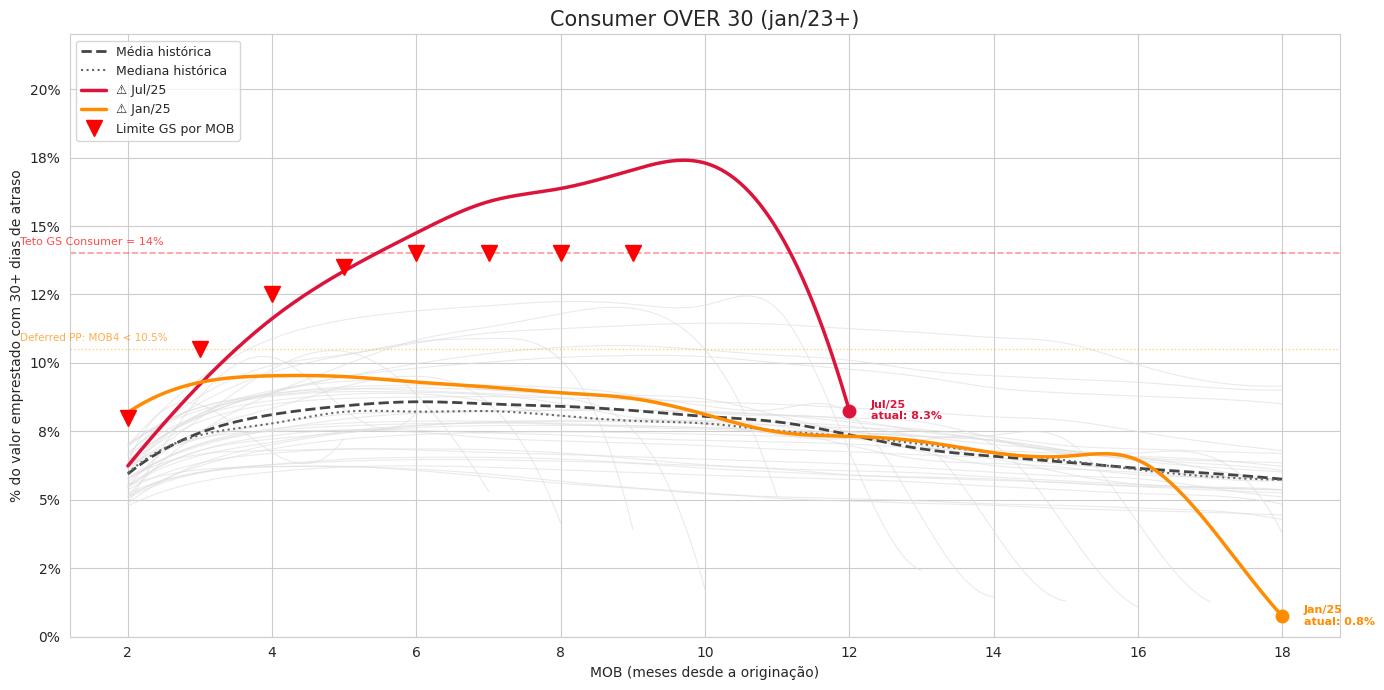

In [ ]:
df_cons = pd.read_csv(f'{DRIVE}/over30_cons.csv')
df_cons['Credit_Creation_Month'] = pd.to_datetime(df_cons['Credit_Creation_Month'])
print(f"Rows: {len(df_cons)} | Vintages: {df_cons['Credit_Creation_Month'].nunique()}")
print(f"OVER_30: {df_cons['OVER_30'].min():.2%} a {df_cons['OVER_30'].max():.2%}")

df_cons_plot = df_cons[(df_cons['MOB'] >= 2) & (df_cons['MOB'] <= 18)].dropna(subset=['OVER_30'])

trigger_cons = {2:0.08, 3:0.105, 4:0.125, 5:0.135, 6:0.14, 7:0.14, 8:0.14, 9:0.14}

def max_breach(group):
    return max(max(0, r['OVER_30'] - trigger_cons.get(int(r['MOB']), 0.14)) for _, r in group.iterrows())

breach_score = df_cons_plot.groupby('Credit_Creation_Month').apply(max_breach).sort_values(ascending=False)
top3_ruins   = breach_score[breach_score > 0].head(3).index.tolist()
saudavel     = breach_score[breach_score == 0].index[-1]

print("Top 3 breach Consumer:", [pd.Timestamp(v).strftime('%b/%y') for v in top3_ruins])
print(f"Saudável: {pd.Timestamp(saudavel).strftime('%b/%y')}")

CORES_RUINS = ['crimson','darkorange','firebrick']
DESTAQUES_CONS = {pd.Timestamp(v).strftime('%Y-%m-%d'): (c, 2.5, f'⚠ {pd.Timestamp(v).strftime("%b/%y")}')
                  for v, c in zip(top3_ruins, CORES_RUINS)}
DESTAQUES_CONS[pd.Timestamp(saudavel).strftime('%Y-%m-%d')] = ('seagreen', 2.5, f'✓ {pd.Timestamp(saudavel).strftime("%b/%y")}')

fig, ax = plt.subplots(figsize=(14, 7))
for vintage in sorted(df_cons_plot['Credit_Creation_Month'].unique()):
    vstr = pd.Timestamp(vintage).strftime('%Y-%m-%d')
    if vstr in DESTAQUES_CONS: continue
    data = df_cons_plot[df_cons_plot['Credit_Creation_Month'] == vintage].sort_values('MOB')
    if len(data) < 4: continue
    xs, ys = smooth(data['MOB'].values, data['OVER_30'].values)
    ax.plot(xs, ys, color='#DDDDDD', linewidth=0.8, alpha=0.6, zorder=1)

media_c   = df_cons_plot.groupby('MOB')['OVER_30'].mean().reset_index().sort_values('MOB')
mediana_c = df_cons_plot.groupby('MOB')['OVER_30'].median().reset_index().sort_values('MOB')
xs_m,   ys_m   = smooth(media_c['MOB'].values,   media_c['OVER_30'].values)
xs_med, ys_med = smooth(mediana_c['MOB'].values, mediana_c['OVER_30'].values)
ax.plot(xs_m,   ys_m,   color='#444444', linewidth=2,   linestyle='--', zorder=4, label='Média histórica')
ax.plot(xs_med, ys_med, color='#666666', linewidth=1.5, linestyle=':',  zorder=4, label='Mediana histórica')

for vstr, (color, lw, label) in DESTAQUES_CONS.items():
    data = df_cons_plot[df_cons_plot['Credit_Creation_Month'] == pd.Timestamp(vstr)].sort_values('MOB')
    if len(data) < 4: continue
    xs, ys = smooth(data['MOB'].values, data['OVER_30'].values)
    ax.plot(xs, ys, color=color, linewidth=lw, zorder=5, label=label)
    last_mob, last_val = data['MOB'].iloc[-1], data['OVER_30'].iloc[-1]
    ax.plot(last_mob, last_val, 'o', color=color, markersize=9, zorder=7)
    ax.text(last_mob+0.3, last_val, f"{pd.Timestamp(vstr).strftime('%b/%y')}\natual: {last_val:.1%}",
            color=color, fontsize=8, fontweight='bold', va='center')

first = True
for mob, val in trigger_cons.items():
    ax.plot(mob, val, 'rv', markersize=11, zorder=7, label='Limite GS por MOB' if first else '_')
    first = False

ax.axhline(y=0.14, color='red', linestyle='--', linewidth=1.2, alpha=0.4)
ax.text(0.5, 0.143, 'Teto GS Consumer = 14%', color='red', fontsize=8, alpha=0.7)
ax.axhline(y=0.105, color='orange', linestyle=':', linewidth=1.0, alpha=0.5)
ax.text(0.5, 0.108, 'Deferred PP: MOB4 < 10.5%', color='darkorange', fontsize=7.5, alpha=0.7)
ax.set_ylim(0, 0.22)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Consumer OVER 30 (jan/23+)', fontsize=15)
ax.set_xlabel('MOB (meses desde a originação)')
ax.set_ylabel('% do valor emprestado com 30+ dias de atraso')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


**Conclusão:** Os breaches Consumer (principalmente **Jul/25**) são estruturalmente diferentes do Merchant.
O mix de rating Consumer é estável — a causa está no **mix de produto**, conforme seção 6.


---
## 5. Consumer — Mix de Rating por Vintage

Diferente do Merchant, o Consumer tem composição de rating **estável** ao longo do tempo.
Isso significa que o breach de Jul/25 **não** foi causado por piora na qualidade de crédito dos tomadores.

**Nota contratual:** novo contrato limita Z a 5% e E a 4%. O portfólio atual tem Z em 17–28% e E em 15–20%.

**Fonte:** `BT_MP_CREDITS_CREDIT_DETAIL`


In [ ]:
query_rating_mix_cons = '''
-- Mix de Rating — Consumer GS
-- Salvar como: rating_mix_cons.csv

WITH base AS (
  SELECT
    LAST_DAY(CRD_CREDIT_CREATION_DATE_ID) AS mes,
    CRD_RISK_ANALYSIS_RATING_ID           AS rating,
    COUNT(*)                              AS qtd,
    SUM(CRD_CREDIT_REQ_AMOUNT)            AS volume
  FROM `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL`
  WHERE
    CRD_CREDIT_CREATION_DT_ID BETWEEN \'2024-06-01\'  AND \'2025-07-31\'
    AND CUS_CUST_ID_BPARTNER = 571062534 AND CUS_CUST_ID_LENDER = 399304599
    AND CRD_CREDIT_STATUS_ID NOT IN (\'REFINANCED\',\'PENDING\',\'ANNULLED\',\'APPROVED\',\'CANCELLED\')
    AND CRD_PRODUCT_ID IN (
      \'PER_CON_MLB_1\',\'CON_MLB_1\',\'MA_CON_MLB\',\'MICRO_MA_CON_MLB\',\'MICRO_CON_MLB\',
      \'per_con_mlb_1\',\'ma_con_mlb\',\'portabi_con_mlb_1\',\'micro_ma_con_mlb\',\'micro_con_mlb\',\'CON_MLB_PJ\'
    )
  GROUP BY 1, 2
),
totais AS (SELECT mes, SUM(volume) AS total FROM base GROUP BY 1)
SELECT b.mes, b.rating, b.qtd,
  ROUND(b.volume/1e6, 2) AS volume_mm, ROUND(b.volume/t.total, 4) AS pct_volume
FROM base b JOIN totais t ON t.mes = b.mes
ORDER BY 1, 2
'''
# print(query_rating_mix_cons)


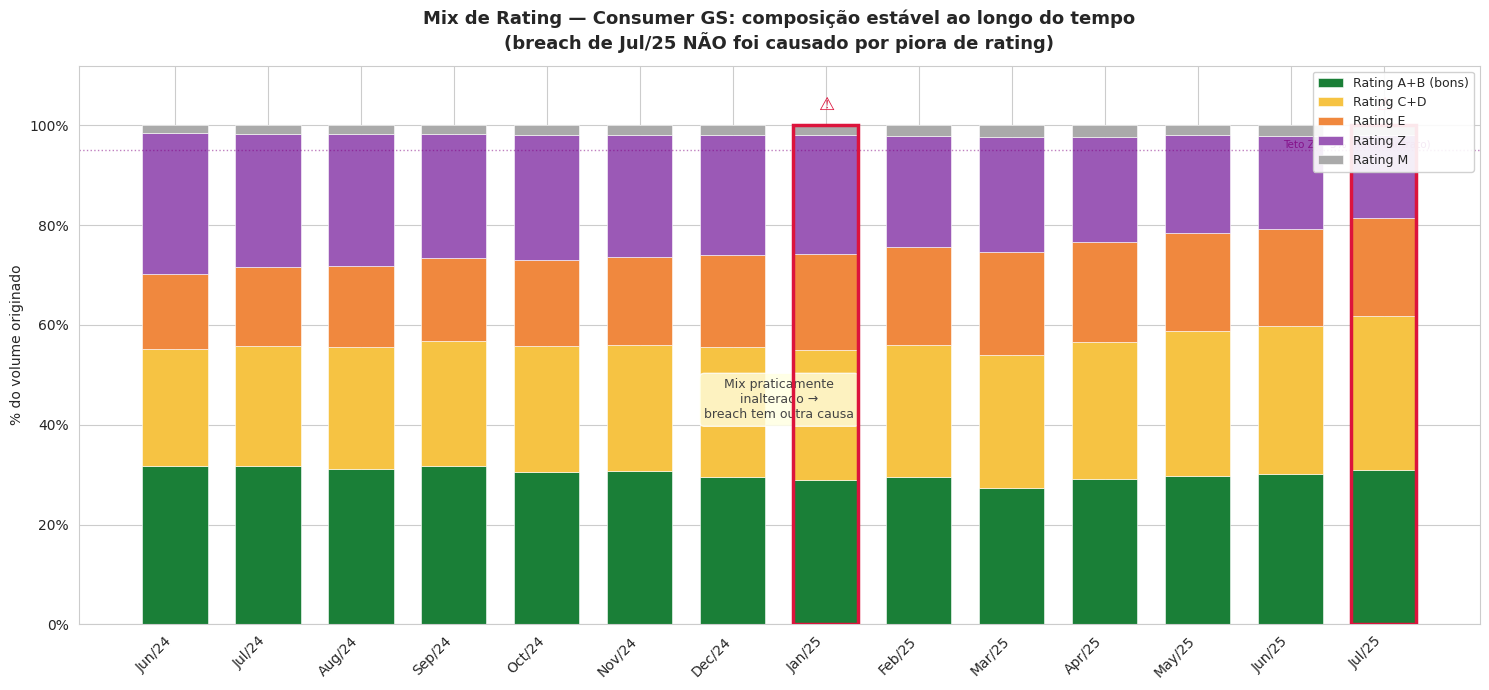

In [ ]:
df_rc = pd.read_csv(f'{DRIVE}/rating_mix_cons.csv')
df_rc['mes'] = pd.to_datetime(df_rc['mes'])

def grupo_cons(r):
    if r in ('A','B'): return 'AB'
    if r in ('C','D'): return 'CD'
    if r == 'E': return 'E'
    if r == 'Z': return 'Z'
    if r == 'M': return 'M'
    return None

df_rc['grupo'] = df_rc['rating'].apply(grupo_cons)
df_rc = df_rc.dropna(subset=['grupo'])
totais_rc = df_rc.groupby('mes')['volume_mm'].sum().rename('total')
df_rc     = df_rc.join(totais_rc, on='mes')
df_rc['pct'] = df_rc['volume_mm'] / df_rc['total']

df_pivc = (df_rc.groupby(['mes','grupo'])['pct'].sum()
           .reset_index().pivot(index='mes', columns='grupo', values='pct').fillna(0).reset_index())
df_pivc['label'] = df_pivc['mes'].dt.strftime('%b/%y')

GRUPOS_C  = ['AB','CD','E','Z','M']
CORES_C   = ['#1a7f37','#f6c343','#f0883e','#9b59b6','#aaaaaa']
LABELS_C  = ['Rating A+B (bons)','Rating C+D','Rating E','Rating Z','Rating M']
RUINS_C   = {'2025-07-31','2025-01-31'}

fig, ax = plt.subplots(figsize=(15, 7))
xs      = range(len(df_pivc))
bottoms = [0.0] * len(df_pivc)

for grupo, cor, leg in zip(GRUPOS_C, CORES_C, LABELS_C):
    vals = df_pivc[grupo].values if grupo in df_pivc.columns else [0]*len(df_pivc)
    ax.bar(xs, vals, bottom=bottoms, color=cor, label=leg, width=0.7, edgecolor='white', linewidth=0.4)
    bottoms = [b+v for b,v in zip(bottoms, vals)]

for i, row in df_pivc.iterrows():
    if row['mes'].strftime('%Y-%m-%d') in RUINS_C:
        ax.bar(i, 1.0, bottom=0, color='none', edgecolor='crimson', linewidth=2.5, width=0.7, zorder=5)
        ax.text(i, 1.03, '⚠', ha='center', fontsize=13, color='crimson')

ax.axhline(y=0.95, color='purple', linestyle=':', linewidth=1.0, alpha=0.5)
ax.text(len(df_pivc)-0.5, 0.955, 'Teto Z = 5% (novo contrato)', color='purple', fontsize=7.5, ha='right', alpha=0.8)
ax.set_xticks(list(xs))
ax.set_xticklabels(df_pivc['label'].tolist(), rotation=45, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1.12)
ax.set_title('Mix de Rating — Consumer GS: composição estável ao longo do tempo\n(breach de Jul/25 NÃO foi causado por piora de rating)', fontsize=13, fontweight='bold', pad=12)
ax.text(6.5, 0.45, 'Mix praticamente\ninalterado →\nbreach tem outra causa', fontsize=9, color='#444',
        ha='center', va='center', bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
ax.set_ylabel('% do volume originado')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


---
## 6. Consumer — Mix de Produto (A causa real do breach de Jul/25)

O breach de Jul/25 foi causado por uma mudança no **tipo de produto** originado, não no perfil de crédito.
Em Jul/25, o **Personal Loan (PER_CON)** saltou para 70% do volume com prazo médio de 7.7 parcelas
(vs. histórico de 2.5–5.4). Empréstimos mais longos têm saldo devedor elevado por mais tempo,
fazendo o OVER 30 picar mais alto e mais tardio (MOB 10 em vez de MOB 5–6).

**Fonte:** `BT_MP_CREDITS_CREDIT_DETAIL`


In [ ]:
query_product_mix_cons = '''
-- Mix de Produto Consumer GS por mês
-- Salvar como: product_mix_cons.csv

WITH base AS (
  SELECT
    LAST_DAY(CRD_CREDIT_CREATION_DATE_ID) AS mes,
    CASE
      WHEN CRD_PRODUCT_ID IN (\'PER_CON_MLB_1\',\'per_con_mlb_1\',\'portabi_con_mlb_1\') THEN \'Personal Loan (PER_CON)\'
      WHEN CRD_PRODUCT_ID IN (\'CON_MLB_1\',\'CON_MLB_PJ\')                               THEN \'Consumer (CON)\'
      WHEN CRD_PRODUCT_ID IN (\'MA_CON_MLB\',\'ma_con_mlb\')                              THEN \'MA Consumer\'
      WHEN CRD_PRODUCT_ID IN (\'MICRO_MA_CON_MLB\',\'micro_ma_con_mlb\',\'MICRO_CON_MLB\',\'micro_con_mlb\') THEN \'Micro Consumer\'
      ELSE CRD_PRODUCT_ID
    END AS produto_grupo,
    COUNT(*)                   AS qtd,
    SUM(CRD_CREDIT_REQ_AMOUNT) AS volume,
    AVG(CRD_CREDIT_INSTALLMENTS) AS avg_parcelas
  FROM `meli-bi-data.WHOWNER.BT_MP_CREDITS_CREDIT_DETAIL`
  WHERE
    CRD_CREDIT_CREATION_DT_ID BETWEEN \'2024-06-01\'  AND \'2025-07-31\'
    AND CUS_CUST_ID_BPARTNER = 571062534 AND CUS_CUST_ID_LENDER = 399304599
    AND CRD_CREDIT_STATUS_ID NOT IN (\'REFINANCED\',\'PENDING\',\'ANNULLED\',\'APPROVED\',\'CANCELLED\')
    AND CRD_PRODUCT_ID IN (
      \'PER_CON_MLB_1\',\'CON_MLB_1\',\'MA_CON_MLB\',\'MICRO_MA_CON_MLB\',\'MICRO_CON_MLB\',
      \'per_con_mlb_1\',\'ma_con_mlb\',\'portabi_con_mlb_1\',\'micro_ma_con_mlb\',\'micro_con_mlb\',\'CON_MLB_PJ\'
    )
  GROUP BY 1, 2
),
totais AS (SELECT mes, SUM(volume) AS total FROM base GROUP BY 1)
SELECT b.mes, b.produto_grupo, b.qtd,
  ROUND(b.volume/1e6, 1) AS volume_mm,
  ROUND(b.volume/t.total, 4) AS pct_volume,
  ROUND(b.avg_parcelas, 1)   AS avg_parcelas
FROM base b JOIN totais t ON t.mes = b.mes
ORDER BY 1, 5 DESC
'''
# print(query_product_mix_cons)


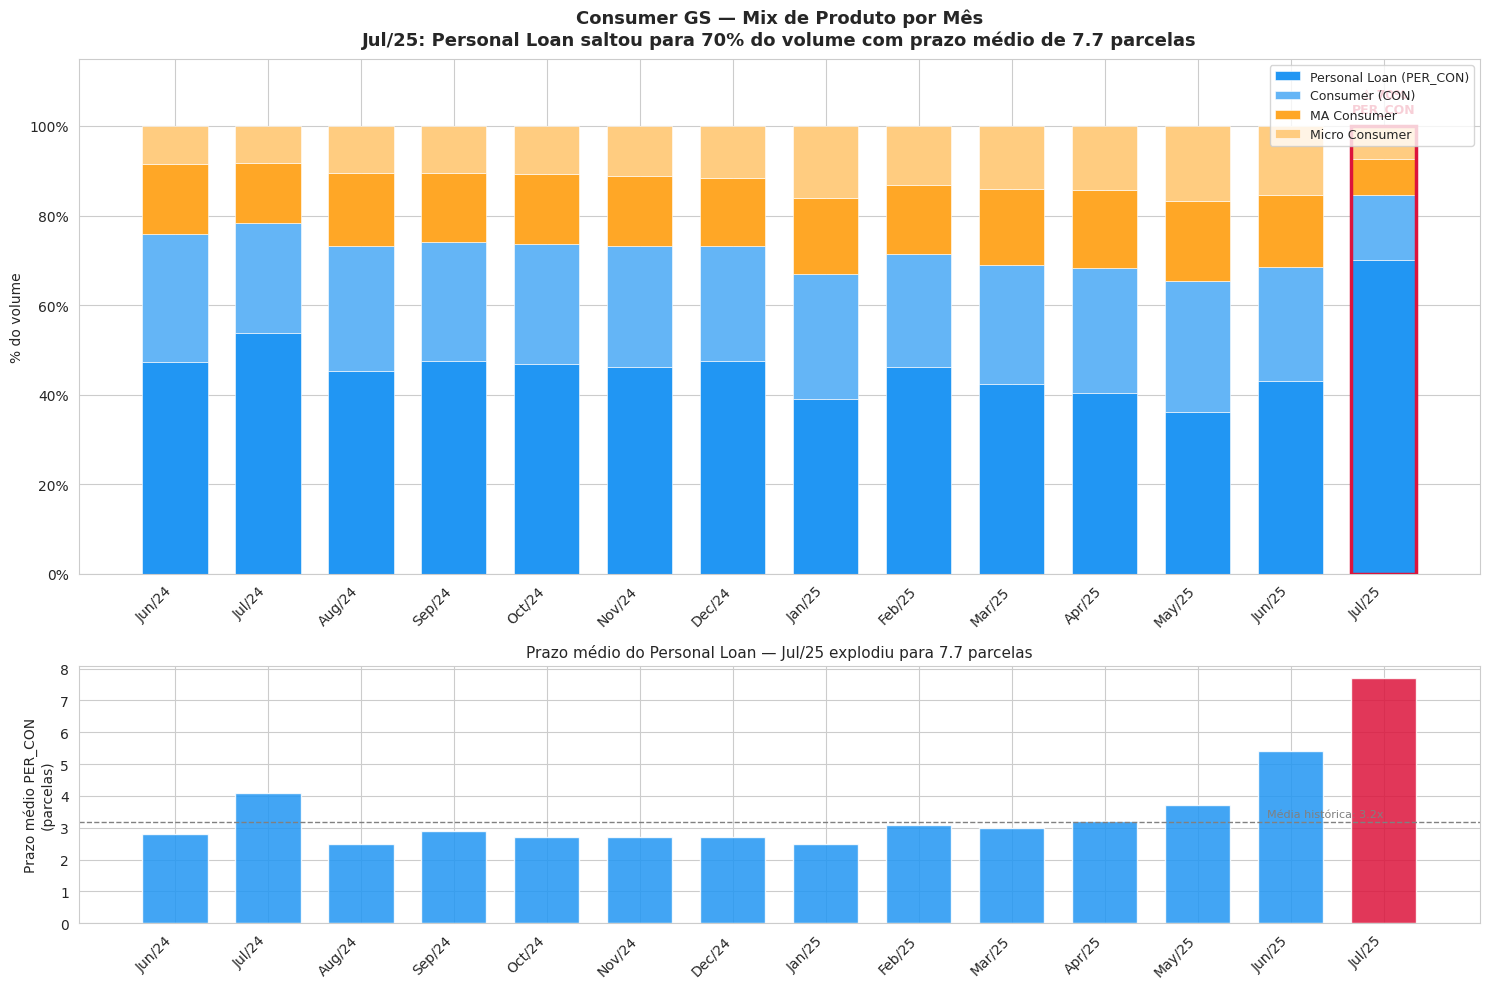

In [ ]:
df_prod = pd.read_csv(f'{DRIVE}/product_mix_cons.csv')
df_prod['mes'] = pd.to_datetime(df_prod['mes'])
df_prod['label'] = df_prod['mes'].dt.strftime('%b/%y')

meses = df_prod['mes'].unique()
labels = [pd.Timestamp(m).strftime('%b/%y') for m in sorted(meses)]
xs = range(len(labels))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1.5]})

PRODS = [('Personal Loan (PER_CON)', '#2196F3'),
         ('Consumer (CON)',          '#64B5F6'),
         ('MA Consumer',             '#FFA726'),
         ('Micro Consumer',          '#FFCC80')]

bottoms = [0.0] * len(labels)
for prod, cor in PRODS:
    vals = []
    for m in sorted(meses):
        row = df_prod[(df_prod['mes'] == m) & (df_prod['produto_grupo'] == prod)]
        vals.append(float(row['pct_volume'].values[0]) if len(row) else 0)
    ax1.bar(xs, vals, bottom=bottoms, color=cor, label=prod, width=0.7, edgecolor='white', linewidth=0.4)
    bottoms = [b+v for b,v in zip(bottoms, vals)]

# Destaque Jul/25 (último mês)
idx_jul = len(labels) - 1
ax1.bar(idx_jul, 1.0, bottom=0, color='none', edgecolor='crimson', linewidth=2.5, width=0.7, zorder=5)
ax1.text(idx_jul, 1.03, '⚠ 70%\nPER_CON', ha='center', fontsize=9, color='crimson', fontweight='bold')

ax1.set_xticks(list(xs))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_ylim(0, 1.15)
ax1.set_title('Consumer GS — Mix de Produto por Mês\nJul/25: Personal Loan saltou para 70% do volume com prazo médio de 7.7 parcelas',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('% do volume')
ax1.legend(loc='upper right', fontsize=9)

# Prazo médio PER_CON
parc_vals = []
for m in sorted(meses):
    row = df_prod[(df_prod['mes'] == m) & (df_prod['produto_grupo'] == 'Personal Loan (PER_CON)')]
    parc_vals.append(float(row['avg_parcelas'].values[0]) if len(row) else 0)

cores_bar = ['crimson' if i == len(labels)-1 else '#2196F3' for i in range(len(labels))]
ax2.bar(xs, parc_vals, color=cores_bar, width=0.7, alpha=0.85)
media_hist = sum(parc_vals[:-1]) / max(len(parc_vals)-1, 1)
ax2.axhline(y=media_hist, color='gray', linestyle='--', linewidth=1)
ax2.text(len(labels)-1, media_hist+0.15, f'Média histórica: {media_hist:.1f}x', color='gray', fontsize=8, ha='right')
ax2.set_xticks(list(xs))
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Prazo médio PER_CON\n(parcelas)')
ax2.set_title('Prazo médio do Personal Loan — Jul/25 explodiu para 7.7 parcelas', fontsize=11)
plt.tight_layout()
plt.show()


### Conclusão — Consumer

| | Histórico Jun/24–Jun/25 | **Jul/25** |
|--|--|--|
| Personal Loan % do volume | 40–54% | **70%** |
| Prazo médio PER_CON | 2.5–5.4 parcelas | **7.7 parcelas** |

O breach foi causado por **mudança estrutural no produto**, não deterioração de crédito.
Empréstimos mais longos têm saldo devedor elevado por mais tempo → OVER 30 pica no MOB 10.

> **Implicação contratual:** o novo contrato limita WA original maturity a 9 meses e
> loans com tenor ≥ 9 meses a 35%. O alongamento dos PER_CON em Jul/25 (7.7 parcelas médias)
> merece monitoramento.
